In [ ]:
# ============================================================================
# CELULA 1: SETUP — Imports, paths, tema vizuala, constante fizice
# ============================================================================
import os, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from scipy import stats

warnings.filterwarnings('ignore')

# === Paths ===
BASE_PATH    = '/content/drive/MyDrive/ML_proiect_licenta'
CSV_PATH     = f'{BASE_PATH}/Renewable.csv'
GRAFICE_PATH = f'{BASE_PATH}/grafice_export'
MODELE_PATH  = f'{BASE_PATH}/export_modele'
CONFIG_PATH  = f'{BASE_PATH}/system_constants.json'

os.makedirs(GRAFICE_PATH, exist_ok=True)
os.makedirs(MODELE_PATH,  exist_ok=True)

# === Tema vizuala ===
SOLAR_PALETTE = ["#FF8C00", "#FFD700", "#1E90FF", "#FF4500", "#4682B4"]
sns.set_theme(style="whitegrid", palette=SOLAR_PALETTE)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 12,
                     'savefig.bbox': 'tight', 'savefig.dpi': 150})

# === Constante fizice ===
BASE_AREA      = 410.0   # m² — suprafata instalatiei din dataset
EFICIENTA_BAZA = 0.18    # 18% la 25°C (panouri policristaline standard)
TEMP_REFERINTA = 25.0    # °C, conditii STC
COEF_TEMP      = -0.004  # -0.4%/°C peste 25°C
TIMP_INTERVAL  = 0.25    # h (interval de 15 minute)

# === Features (10) si target ===
FEATURES = [
    'GHI',        # Radiatie solara globala orizontala (W/m²)
    'temp',       # Temperatura ambientala (Celsius)
    'pressure',   # Presiune atmosferica (hPa)
    'humidity',   # Umiditate relativa (%)
    'clouds_all', # Acoperire cu nori (%)
    'rain_1h',    # Precipitatii (mm/h)
    'snow_1h',    # Ninsori (mm/h)
    'wind_speed', # Viteza vantului (m/s)
    'dayLength',  # Durata zilei (minute) — sezonalitate
    'hour',       # Ora din zi (0-23)
]
TARGET = 'Energy delta[Wh]'

print("=" * 60)
print(" SETUP COMPLET")
print("=" * 60)
print(f"  Suprafata referinta : {BASE_AREA} m²")
print(f"  Eficienta baza      : {EFICIENTA_BAZA*100}%")
print(f"  Timp interval       : {TIMP_INTERVAL} h (15 min)")
print(f"  Features            : {len(FEATURES)}")
print(f"  Target              : {TARGET}")
print("=" * 60)

 SETUP COMPLET
  Suprafata referinta : 410.0 m²
  Eficienta baza      : 18.0%
  Timp interval       : 0.25 h (15 min)
  Features            : 10
  Target              : Energy delta[Wh]


In [ ]:
# ============================================================================
# CELULA 2: INCARCARE DATE
# ============================================================================
print("Incarcam datele din Renewable.csv...")
df = pd.read_csv(CSV_PATH)
df['Time'] = pd.to_datetime(df['Time'])
df.set_index('Time', inplace=True)

print(f"✓ {len(df):,} randuri | {len(df.columns)} coloane")
print(f"  Perioada: {df.index.min()} → {df.index.max()}")
print(f"  Rezolutie: {df.index[1] - df.index[0]}")
print("\n--- Statistici variabile cheie ---")
print(df[['GHI', TARGET, 'temp', 'humidity', 'clouds_all']].describe().round(2))

nan_count = df[FEATURES + [TARGET]].isna().sum().sum()
print(f"\nNaN-uri in features+target: {nan_count}")

Incarcam datele din Renewable.csv...
✓ 195,886 randuri | 16 coloane
  Perioada: 2017-01-01 00:00:00 → 2022-08-31 17:45:00
  Rezolutie: 0 days 00:15:00

--- Statistici variabile cheie ---
             GHI  Energy delta[Wh]       temp   humidity  clouds_all
count  195886.00         195886.00  195886.00  195886.00   195886.00
mean       32.42            575.61       9.77      79.85       66.00
std        52.07           1046.48       7.99      15.59       36.63
min         0.00              0.00     -16.60      22.00        0.00
25%         0.00              0.00       3.60      70.00       34.00
50%         1.30              0.00       9.30      84.00       82.00
75%        46.40            584.00      15.70      92.00      100.00
max       229.20           5020.00      35.80     100.00      100.00

NaN-uri in features+target: 0


In [ ]:
# ============================================================================
# CELULA 3: CURATARE ANOMALII FIZICE
# ============================================================================
print(f"Inainte de curatare: {len(df):,} randuri")

# Anomalie 1: "Energie fantoma noaptea" — GHI=0 dar Energy>0
anomalii_noapte = (df['GHI'] == 0) & (df[TARGET] > 0)

# Anomalie 2: "Invertor picat ziua" — GHI>20 dar Energy aproape zero
anomalii_zi = (df['GHI'] > 20) & (df[TARGET] < 10)

df_clean = df[~(anomalii_noapte | anomalii_zi)].copy()
df_clean = df_clean.dropna(subset=FEATURES + [TARGET])

print(f"  Eliminate (fantoma noapte) : {anomalii_noapte.sum():,}")
print(f"  Eliminate (invertor picat) : {anomalii_zi.sum():,}")
print(f"  Dupa curatare              : {len(df_clean):,} randuri")
print(f"  Procent pastrate           : {100*len(df_clean)/len(df):.2f}%")
print("✓ Date curatate")

Inainte de curatare: 195,886 randuri
  Eliminate (fantoma noapte) : 0
  Eliminate (invertor picat) : 0
  Dupa curatare              : 195,886 randuri
  Procent pastrate           : 100.00%
✓ Date curatate


 SPLIT CRONOLOGIC TRAIN / TEST (80% / 20%)
  Train: 156,708 randuri  | 2017-01-01 00:00:00 → 2021-07-04 04:00:00
  Test : 39,178 randuri  | 2021-07-04 04:15:00  → 2022-08-31 17:45:00

  PR train : (42612, 10) | PR test: (11825, 10)
  Randuri cu GHI>20 si PR valid: 54,437

  Mediana PR: 0.748  ✓ BINE (0.6-0.9)


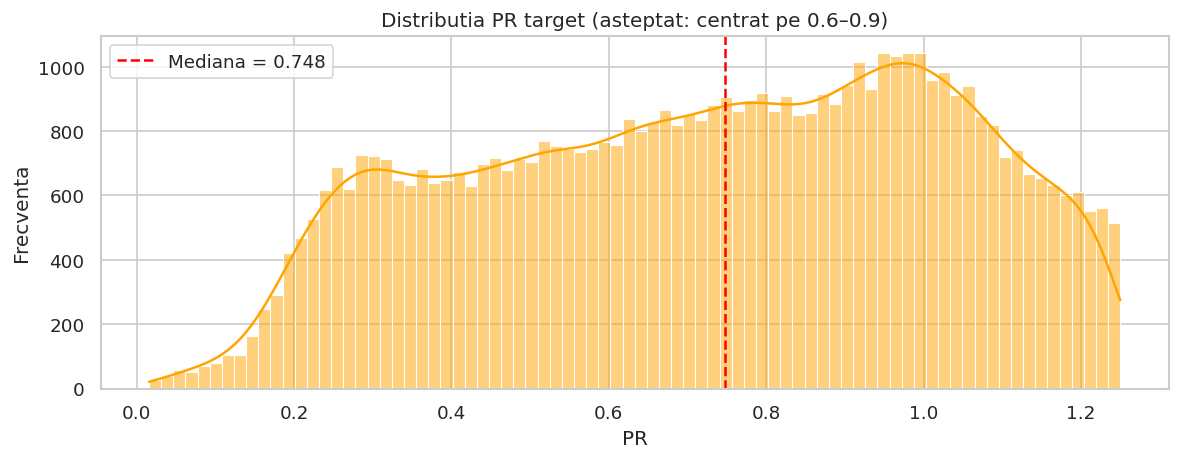

In [ ]:
# ============================================================================
# CELULA 4: SPLIT CRONOLOGIC 80/20 + CONSTRUIRE PR TARGET
#
# Doua seturi de date:
#   (X_train, y_train) / (X_test, y_test)   → Energy Wh, pentru comparatia
#                                               celor 5 modele
#   (Xtrain_pr, ytrain_pr) / (Xtest_pr, ...)→ PR adimensional, doar pentru
#                                               XGBoost Quantile de productie
# ============================================================================

# --- Split Energy (pentru modelele de comparatie) ---
X = df_clean[FEATURES]
y = df_clean[TARGET]

split_idx = int(len(X) * 0.8)
X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]

print("=" * 60)
print(" SPLIT CRONOLOGIC TRAIN / TEST (80% / 20%)")
print("=" * 60)
print(f"  Train: {len(X_train):,} randuri  | {X_train.index.min()} → {X_train.index.max()}")
print(f"  Test : {len(X_test):,} randuri  | {X_test.index.min()}  → {X_test.index.max()}")

# --- Construire PR target ---
PR_COL = 'PR_target'
EPS    = 1e-6

df_pr     = df_clean.copy()
scale_all = df_pr['GHI'] * BASE_AREA * EFICIENTA_BAZA * TIMP_INTERVAL

df_pr[PR_COL] = np.where(
    df_pr['GHI'] > EPS,
    df_pr[TARGET] / scale_all,
    np.nan
)

# Filtram: GHI > 20 (stabilitate PR), PR in [0, 1.25] (fara valori absurde)
mask_pr = (
    df_pr['GHI'].gt(20) &
    df_pr[PR_COL].notna() &
    np.isfinite(df_pr[PR_COL]) &
    df_pr[PR_COL].between(0, 1.25)
)
df_pr_model = df_pr.loc[mask_pr].copy()

X_pr_all = df_pr_model[FEATURES]
y_pr_all = df_pr_model[PR_COL]

# Pastram split-ul cronologic
train_idx_pr = X_train.index[X_train.index.isin(X_pr_all.index)]
test_idx_pr  = X_test.index[X_test.index.isin(X_pr_all.index)]

Xtrain_pr       = X_pr_all.loc[train_idx_pr].copy()
Xtest_pr        = X_pr_all.loc[test_idx_pr].copy()
ytrain_pr       = y_pr_all.loc[train_idx_pr].copy()
ytest_pr        = y_pr_all.loc[test_idx_pr].copy()
ytest_energy_pr = df_pr_model.loc[test_idx_pr, TARGET].copy()  # Wh, pentru evaluare quantile

print(f"\n  PR train : {Xtrain_pr.shape} | PR test: {Xtest_pr.shape}")
print(f"  Randuri cu GHI>20 si PR valid: {len(df_pr_model):,}")

median_pr = df_pr_model[PR_COL].median()
print(f"\n  Mediana PR: {median_pr:.3f}", end="  ")
print("✓ BINE (0.6-0.9)" if 0.5 <= median_pr <= 0.95 else "⚠ Verifica constantele!")

# Grafic distributie PR
plt.figure(figsize=(10, 4))
sns.histplot(df_pr_model[PR_COL], bins=80, kde=True, color="orange")
plt.axvline(median_pr, color='red', linestyle='--', label=f'Mediana = {median_pr:.3f}')
plt.title("Distributia PR target (asteptat: centrat pe 0.6–0.9)")
plt.xlabel("PR"); plt.ylabel("Frecventa"); plt.legend()
plt.tight_layout(); plt.show()

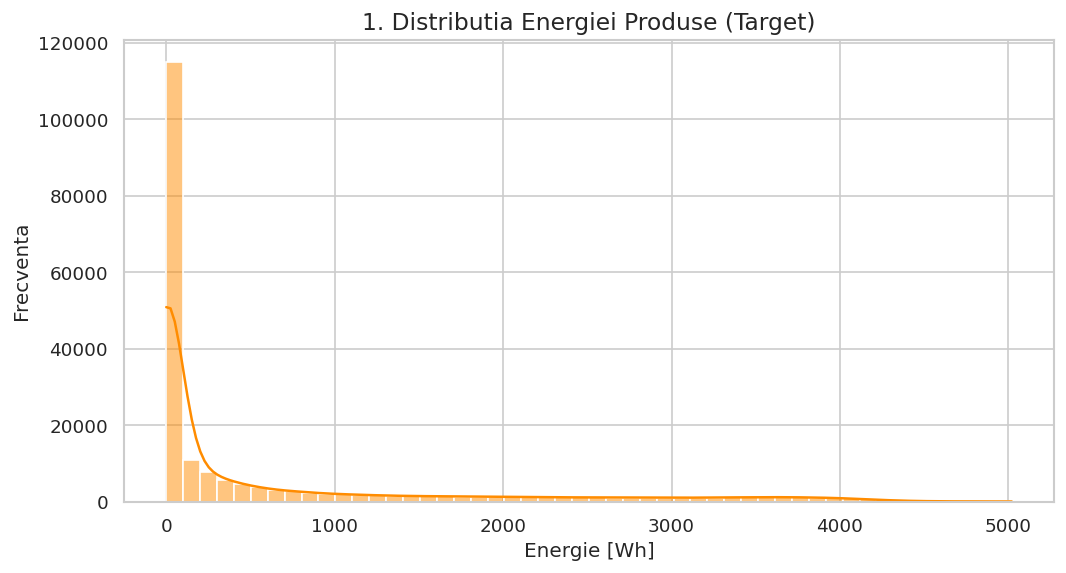

✓ Grafic 1


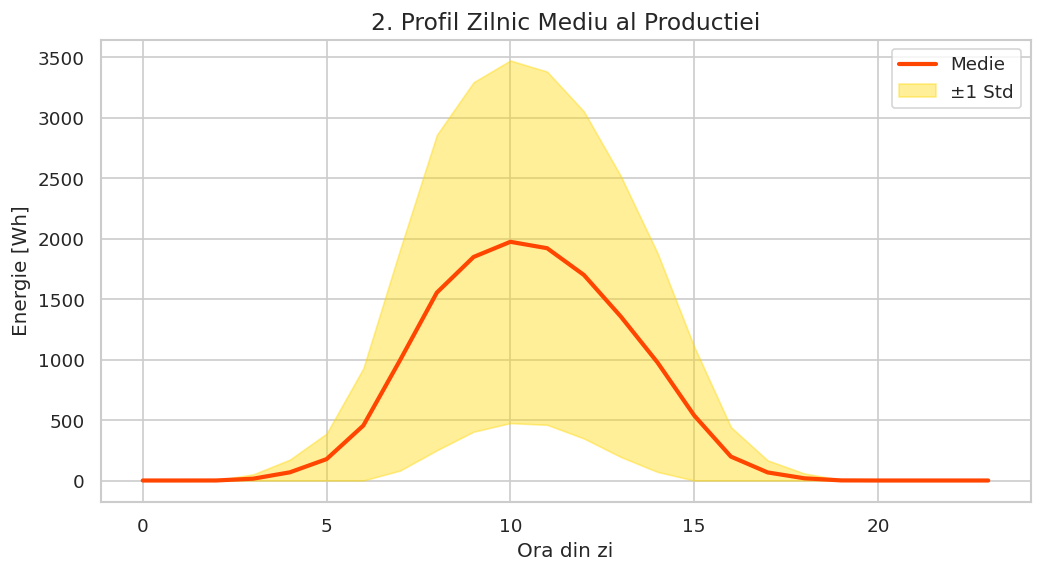

✓ Grafic 2


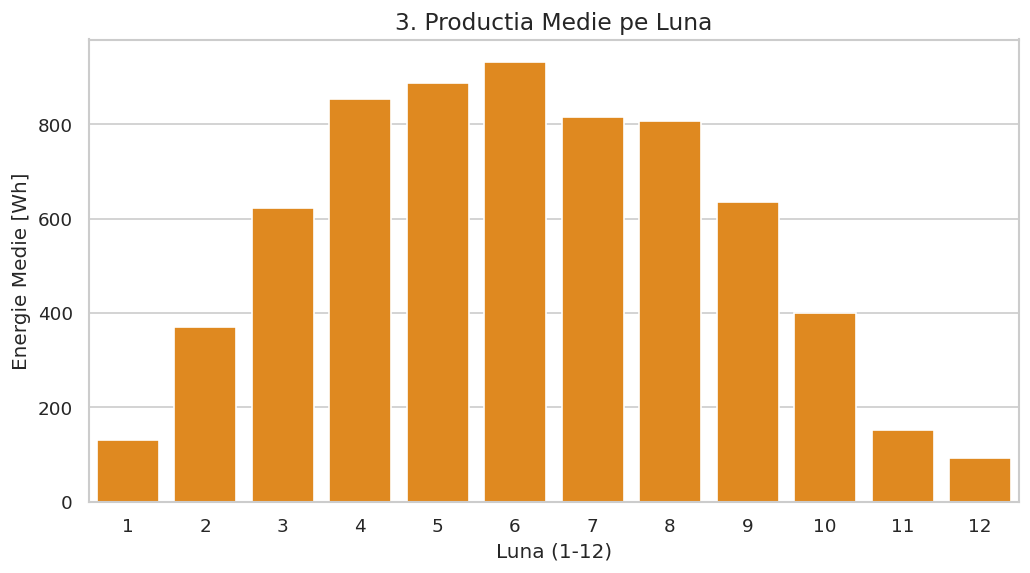

✓ Grafic 3


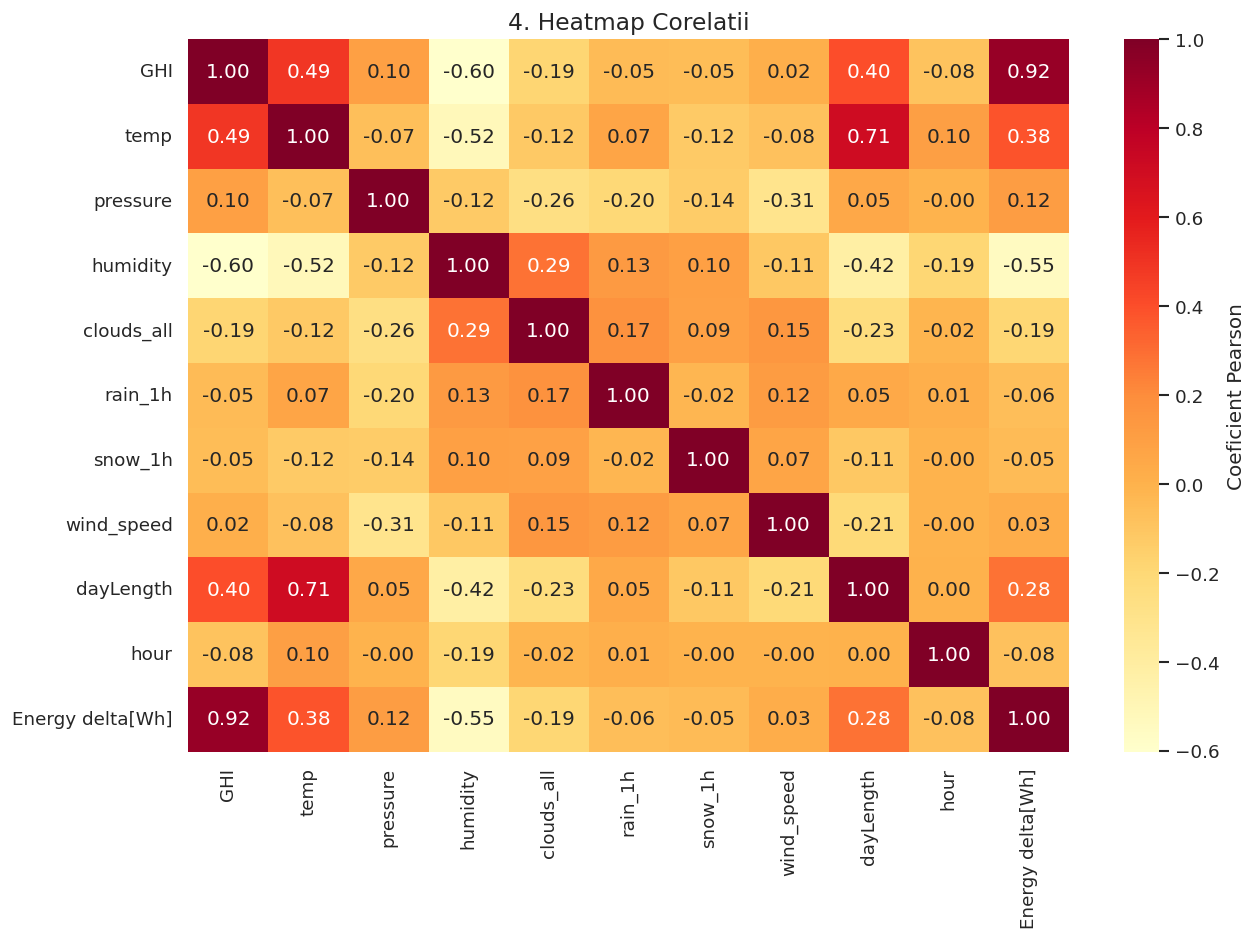

✓ Grafic 4


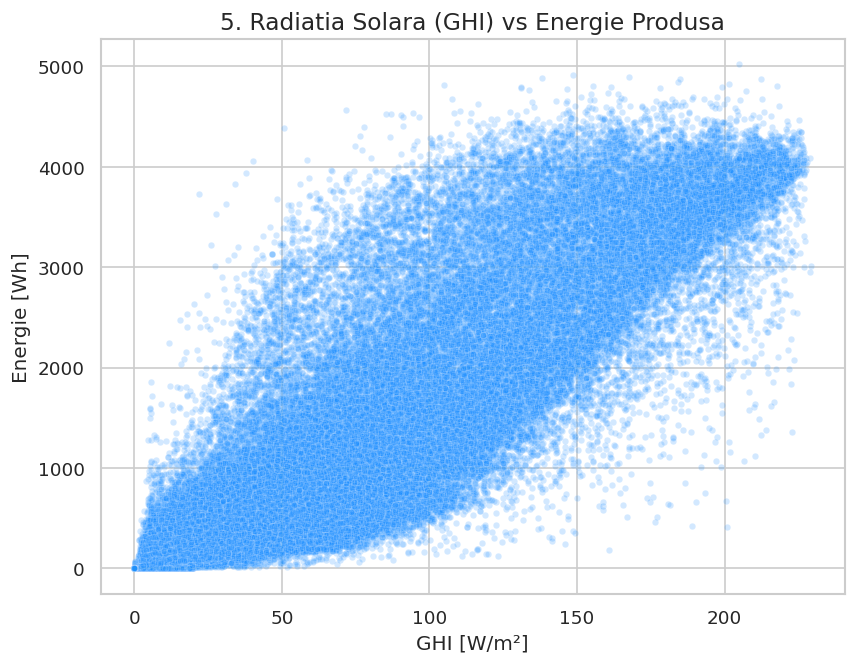

✓ Grafic 5

=== EDA COMPLET ===


In [ ]:
# ============================================================================
# CELULA 5: EDA — 5 GRAFICE PENTRU LUCRARE
# ============================================================================

# Grafic 1: Histograma distributiei target
plt.figure(figsize=(10, 5))
sns.histplot(y, bins=50, color=SOLAR_PALETTE[0], kde=True)
plt.title('1. Distributia Energiei Produse (Target)', fontsize=14)
plt.xlabel('Energie [Wh]'); plt.ylabel('Frecventa')
plt.savefig(f'{GRAFICE_PATH}/1_histograma_energie.png'); plt.show()
print("✓ Grafic 1")

# Grafic 2: Profil zilnic mediu
daily = df_clean.groupby('hour')[TARGET].agg(['mean', 'std'])
plt.figure(figsize=(10, 5))
plt.plot(daily.index, daily['mean'], color=SOLAR_PALETTE[3], linewidth=2.5, label='Medie')
plt.fill_between(daily.index,
                 np.maximum(0, daily['mean'] - daily['std']),
                 daily['mean'] + daily['std'],
                 color=SOLAR_PALETTE[1], alpha=0.4, label='±1 Std')
plt.title('2. Profil Zilnic Mediu al Productiei', fontsize=14)
plt.xlabel('Ora din zi'); plt.ylabel('Energie [Wh]'); plt.legend()
plt.savefig(f'{GRAFICE_PATH}/2_profil_zilnic.png'); plt.show()
print("✓ Grafic 2")

# Grafic 3: Profil sezonier
monthly = df_clean.groupby('month')[TARGET].mean()
plt.figure(figsize=(10, 5))
sns.barplot(x=monthly.index, y=monthly.values, color=SOLAR_PALETTE[0])
plt.title('3. Productia Medie pe Luna', fontsize=14)
plt.xlabel('Luna (1-12)'); plt.ylabel('Energie Medie [Wh]')
plt.savefig(f'{GRAFICE_PATH}/3_profil_sezonier.png'); plt.show()
print("✓ Grafic 3")

# Grafic 4: Heatmap corelatii
plt.figure(figsize=(11, 8))
corr = df_clean[FEATURES + [TARGET]].corr()
sns.heatmap(corr, annot=True, cmap='YlOrRd', fmt='.2f',
            cbar_kws={'label': 'Coeficient Pearson'})
plt.title('4. Heatmap Corelatii', fontsize=14); plt.tight_layout()
plt.savefig(f'{GRAFICE_PATH}/4_heatmap_corelatii.png'); plt.show()
print("✓ Grafic 4")

# Grafic 5: Scatter GHI vs Energy
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df_clean['GHI'], y=df_clean[TARGET],
                alpha=0.2, color=SOLAR_PALETTE[2], s=15)
plt.title('5. Radiatia Solara (GHI) vs Energie Produsa', fontsize=14)
plt.xlabel('GHI [W/m²]'); plt.ylabel('Energie [Wh]')
plt.savefig(f'{GRAFICE_PATH}/5_scatter_ghi_energy.png'); plt.show()
print("✓ Grafic 5")

print("\n=== EDA COMPLET ===")

In [ ]:
# ============================================================================
# CELULA 6: FUNCTII HELPER + DICTIONARE GLOBALE
# ============================================================================

def mape(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    mask = y_true != 0
    return np.nan if mask.sum() == 0 else np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def get_metrics(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    return {
        'MAE':  mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2':   r2_score(y_true, y_pred),
        'MAPE': mape(y_true, y_pred),
    }

def diebold_mariano_test(y_true, pred1, pred2):
    e1 = np.abs(np.asarray(y_true) - np.asarray(pred1))
    e2 = np.abs(np.asarray(y_true) - np.asarray(pred2))
    d  = e1 - e2
    n  = len(d)
    var_d = np.var(d, ddof=1)
    if var_d == 0:
        return 0.0, 1.0
    stat = np.mean(d) / np.sqrt(var_d / n)
    return stat, 2 * (1 - stats.norm.cdf(abs(stat)))

# Dictionare globale — populate de celulele 7-11
predictions_dict = {}  # model_name → array predictii pe X_test (Energy Wh)
metrics_dict     = {}  # model_name → dict MAE/RMSE/R2/MAPE
models_dict      = {}  # model_name → obiect model

print("✓ Functii helper definite")
print("✓ Dictionare goale initializate")
print("→ Ruleaza celulele 7-11 pentru antrenarea modelelor")

✓ Functii helper definite
✓ Dictionare goale initializate
→ Ruleaza celulele 7-11 pentru antrenarea modelelor


In [ ]:
# ============================================================================
# CELULA 7: MODEL 1/5 — REGRESIE LINIARA (BASELINE) pe Energy Wh
# ============================================================================
print("=" * 60)
print(" MODEL 1/5: REGRESIE LINIARA (BASELINE)")
print("=" * 60)

start    = time.time()
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred  = lr_model.predict(X_test)
elapsed  = time.time() - start

models_dict['LinReg']      = lr_model
predictions_dict['LinReg'] = lr_pred
metrics_dict['LinReg']     = get_metrics(y_test, lr_pred)

m = metrics_dict['LinReg']
print(f"✓ Antrenat in {elapsed:.1f}s")
print(f"  MAE  : {m['MAE']:.2f} Wh")
print(f"  RMSE : {m['RMSE']:.2f} Wh")
print(f"  R²   : {m['R2']:.4f}")
print(f"  MAPE : {m['MAPE']:.2f}%")

joblib.dump(lr_model, f'{MODELE_PATH}/model_linreg.pkl')
print(f"✓ Salvat: model_linreg.pkl")

# Coeficienti pentru lucrare
coef_df = pd.DataFrame({'Feature': FEATURES, 'Coeficient': lr_model.coef_})
coef_df = coef_df.reindex(coef_df['Coeficient'].abs().sort_values(ascending=False).index)
print("\n--- Coeficienti (sortat dupa importanta) ---")
print(coef_df.to_string(index=False))

 MODEL 1/5: REGRESIE LINIARA (BASELINE)
✓ Antrenat in 0.1s
  MAE  : 254.31 Wh
  RMSE : 407.92 Wh
  R²   : 0.8488
  MAPE : 160.14%
✓ Salvat: model_linreg.pkl

--- Coeficienti (sortat dupa importanta) ---
   Feature  Coeficient
   snow_1h -151.641465
       GHI   19.483806
   rain_1h    6.301582
      temp   -5.423605
wind_speed   -2.292525
  humidity   -1.110157
  pressure    1.099557
clouds_all   -0.682429
 dayLength   -0.469685
      hour   -0.144728


In [ ]:
# ============================================================================
# CELULA 8: MODEL 2/5 — ARMAX (SARIMAX order=(1,0,1)) pe Energy Wh
# FAST_MODE=True → 30k puncte (recomandat pentru Colab)
# FAST_MODE=False → full data (15-40 min)
# ============================================================================
FAST_MODE = True  # ← schimba la False daca vrei full data

print("=" * 60)
print(" MODEL 2/5: ARMAX (SARIMAX(1,0,1))")
print("=" * 60)

if FAST_MODE:
    armax_n       = min(30000, len(X_train))
    X_train_armax = X_train.iloc[-armax_n:]
    y_train_armax = y_train.iloc[-armax_n:]
    print(f"⚡ FAST_MODE: {len(X_train_armax):,} randuri")
else:
    X_train_armax = X_train
    y_train_armax = y_train
    print("⏰ Mod complet — poate dura 15-40 min")

start       = time.time()
armax_model = SARIMAX(y_train_armax, exog=X_train_armax, order=(1, 0, 1))
print("Fitting... asteapta")
armax_fit   = armax_model.fit(disp=False, maxiter=50)

armax_pred = armax_fit.predict(
    start=len(y_train_armax),
    end=len(y_train_armax) + len(y_test) - 1,
    exog=X_test
).values
elapsed = time.time() - start

models_dict['ARMAX']      = armax_fit
predictions_dict['ARMAX'] = armax_pred
metrics_dict['ARMAX']     = get_metrics(y_test, armax_pred)

m = metrics_dict['ARMAX']
print(f"✓ Antrenat in {elapsed/60:.1f} min")
print(f"  MAE  : {m['MAE']:.2f} Wh")
print(f"  RMSE : {m['RMSE']:.2f} Wh")
print(f"  R²   : {m['R2']:.4f}")
print(f"  MAPE : {m['MAPE']:.2f}%")

joblib.dump(armax_fit, f'{MODELE_PATH}/model_armax.pkl')
print("✓ Salvat: model_armax.pkl")

 MODEL 2/5: ARMAX (SARIMAX(1,0,1))
⚡ FAST_MODE: 30,000 randuri
Fitting... asteapta
✓ Antrenat in 0.9 min
  MAE  : 244.50 Wh
  RMSE : 409.65 Wh
  R²   : 0.8475
  MAPE : 142.28%
✓ Salvat: model_armax.pkl


In [ ]:
# ============================================================================
# CELULA 9: MODEL 3/5 — HIBRID ARX + ARMA pe Energy Wh
# Etapa 1: ARX (regresie liniara pe exogene)
# Etapa 2: ARMA(1,0,1) pe reziduurile ARX
# Predictie finala: y = y_ARX + reziduu_ARMA
# ============================================================================
print("=" * 60)
print(" MODEL 3/5: HIBRID ARX + ARMA")
print("=" * 60)

start = time.time()

# Etapa 1: ARX
print("[1/2] ARX...")
arx_model       = LinearRegression()
arx_model.fit(X_train, y_train)
arx_train_pred  = arx_model.predict(X_train)
arx_test_pred   = arx_model.predict(X_test)
residuals_train = y_train.values - arx_train_pred
print(f"  RMSE rezidual ARX: {np.sqrt(np.mean(residuals_train**2)):.2f} Wh")

# Etapa 2: ARMA pe reziduuri
print("[2/2] ARMA pe reziduuri...")
arma_model = ARIMA(residuals_train, order=(1, 0, 1))
arma_fit   = arma_model.fit()

arma_test_pred = arma_fit.predict(start=len(y_train), end=len(y_train) + len(y_test) - 1)
hibrid_pred    = arx_test_pred + np.asarray(arma_test_pred)
elapsed        = time.time() - start

models_dict['Hibrid']      = {'arx': arx_model, 'arma': arma_fit}
predictions_dict['Hibrid'] = hibrid_pred
metrics_dict['Hibrid']     = get_metrics(y_test, hibrid_pred)

m = metrics_dict['Hibrid']
print(f"✓ Antrenat in {elapsed:.1f}s")
print(f"  MAE  : {m['MAE']:.2f} Wh")
print(f"  RMSE : {m['RMSE']:.2f} Wh")
print(f"  R²   : {m['R2']:.4f}")
print(f"  MAPE : {m['MAPE']:.2f}%")

joblib.dump(models_dict['Hibrid'], f'{MODELE_PATH}/model_hibrid.pkl')
print("✓ Salvat: model_hibrid.pkl")

 MODEL 3/5: HIBRID ARX + ARMA
[1/2] ARX...
  RMSE rezidual ARX: 388.09 Wh
[2/2] ARMA pe reziduuri...
✓ Antrenat in 14.2s
  MAE  : 254.29 Wh
  RMSE : 407.88 Wh
  R²   : 0.8488
  MAPE : 160.12%
✓ Salvat: model_hibrid.pkl


In [ ]:
# ============================================================================
# CELULA 10: MODEL 4/5 — RANDOM FOREST pe Energy Wh
# ============================================================================
print("=" * 60)
print(" MODEL 4/5: RANDOM FOREST")
print("=" * 60)

RF_PARAMS = {
    'n_estimators':    500,
    'max_depth':       10,   # redus pentru a preveni memorarea
    'min_samples_leaf': 10,  # crescut pentru generalizare
    'min_samples_split': 20,
    'max_features':    0.6,
    'random_state':    42,
    'n_jobs':          -1,
}

start    = time.time()
rf_model = RandomForestRegressor(**RF_PARAMS)
rf_model.fit(X_train, y_train)
rf_pred  = rf_model.predict(X_test)
elapsed  = time.time() - start

# Gap train-test (indicator de overfitting — tinta < 20%)
rf_train_pred = rf_model.predict(X_train)
mae_train     = mean_absolute_error(y_train, rf_train_pred)
mae_test      = mean_absolute_error(y_test, rf_pred)
gap           = (mae_test - mae_train) / mae_train * 100

models_dict['RandomForest']      = rf_model
predictions_dict['RandomForest'] = rf_pred
metrics_dict['RandomForest']     = get_metrics(y_test, rf_pred)

m = metrics_dict['RandomForest']
print(f"✓ Antrenat in {elapsed:.1f}s")
print(f"  MAE train : {mae_train:.2f} Wh")
print(f"  MAE test  : {mae_test:.2f} Wh")
print(f"  Gap       : {gap:+.1f}%  {'✓ OK' if gap < 20 else '⚠ Overfitting'}")
print(f"  R²        : {m['R2']:.4f}")
print(f"  MAPE      : {m['MAPE']:.2f}%")

joblib.dump(rf_model, f'{MODELE_PATH}/model_randomforest.pkl')
print("✓ Salvat: model_randomforest.pkl")

 MODEL 4/5: RANDOM FOREST
✓ Antrenat in 74.4s
  MAE train : 110.20 Wh
  MAE test  : 127.11 Wh
  Gap       : +15.3%  ✓ OK
  R²        : 0.9255
  MAPE      : 63.51%
✓ Salvat: model_randomforest.pkl


In [ ]:
# ============================================================================
# CELULA 11: MODEL 5/5 — XGBOOST STANDARD pe Energy Wh
# (pentru comparatia academica — NU e modelul de productie)
# Antrenam pe X_train/y_train (Energy Wh), nu pe ytrain_pr
# ============================================================================
print("=" * 60)
print(" MODEL 5/5: XGBOOST STANDARD (comparatie academica)")
print("=" * 60)

start = time.time()

xgb_param_dist = {
    'n_estimators':    [100, 200, 300, 500],
    'learning_rate':   [0.01, 0.05, 0.1, 0.15],
    'max_depth':       [3, 5, 7, 10],
    'subsample':       [0.7, 0.8, 1.0],
    'colsample_bytree':[0.7, 0.8, 1.0],
    'min_child_weight':[1, 3, 5],
}

xgb_base = xgb.XGBRegressor(objective='reg:squarederror',
                             random_state=42, n_jobs=-1, verbosity=0)

# Tuning pe ultimele 50k puncte din train (mai rapid)
tune_n   = min(50000, len(X_train))
X_tune   = X_train.iloc[-tune_n:]
y_tune   = y_train.iloc[-tune_n:]

xgb_search = RandomizedSearchCV(
    estimator=xgb_base, param_distributions=xgb_param_dist,
    n_iter=15, cv=3, scoring='neg_mean_absolute_error',
    random_state=42, n_jobs=1, verbose=1
)
xgb_search.fit(X_tune, y_tune)

tune_elapsed = time.time() - start
print(f"✓ Tuning in {tune_elapsed/60:.1f} min | Best params: {xgb_search.best_params_}")

# Refit pe full training data cu cei mai buni parametri
xgb_best = xgb.XGBRegressor(**xgb_search.best_params_,
                             objective='reg:squarederror',
                             random_state=42, n_jobs=-1, verbosity=0)
xgb_best.fit(X_train, y_train)       # ← X_train/y_train (Energy Wh)
xgb_pred = xgb_best.predict(X_test)  # ← rezultat in Wh direct
elapsed  = time.time() - start

models_dict['XGBoost']      = xgb_best
predictions_dict['XGBoost'] = xgb_pred
metrics_dict['XGBoost']     = get_metrics(y_test, xgb_pred)

m = metrics_dict['XGBoost']
print(f"✓ Timp total: {elapsed/60:.1f} min")
print(f"  MAE  : {m['MAE']:.2f} Wh")
print(f"  RMSE : {m['RMSE']:.2f} Wh")
print(f"  R²   : {m['R2']:.4f}")
print(f"  MAPE : {m['MAPE']:.2f}%")

joblib.dump(xgb_best, f'{MODELE_PATH}/model_xgboost_comparatie.pkl')
joblib.dump(xgb_search.best_params_, f'{MODELE_PATH}/xgb_best_params.pkl')
print("✓ Salvat: model_xgboost_comparatie.pkl")

 MODEL 5/5: XGBOOST STANDARD (comparatie academica)
Fitting 3 folds for each of 15 candidates, totalling 45 fits
✓ Tuning in 0.9 min | Best params: {'subsample': 0.8, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 10, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
✓ Timp total: 1.0 min
  MAE  : 125.16 Wh
  RMSE : 283.18 Wh
  R²   : 0.9271
  MAPE : 57.17%
✓ Salvat: model_xgboost_comparatie.pkl


In [ ]:
# ============================================================================
# CELULA 12: TABEL COMPARATIE CELE 5 MODELE
# ============================================================================
metrics_df        = pd.DataFrame(metrics_dict).T.round(2)
metrics_df_sorted = metrics_df.sort_values('MAE')

print("=" * 60)
print(" COMPARATIE METRICA (sortat dupa MAE)")
print("=" * 60)
print(metrics_df_sorted.to_string())
print("=" * 60)

WINNER = metrics_df['MAE'].idxmin()
print(f"\n🏆 WINNER: {WINNER}")
print(f"   MAE  = {metrics_df.loc[WINNER, 'MAE']:.2f} Wh")
print(f"   R²   = {metrics_df.loc[WINNER, 'R2']:.4f}")
print(f"   RMSE = {metrics_df.loc[WINNER, 'RMSE']:.2f} Wh")

metrics_df_sorted.to_csv(f'{GRAFICE_PATH}/tabel_metrici_modele.csv')
print(f"\n✓ Tabel salvat: tabel_metrici_modele.csv")

 COMPARATIE METRICA (sortat dupa MAE)
                 MAE    RMSE    R2    MAPE
XGBoost       125.16  283.18  0.93   57.17
RandomForest  127.11  286.36  0.93   63.51
ARMAX         244.50  409.65  0.85  142.28
Hibrid        254.29  407.88  0.85  160.12
LinReg        254.31  407.92  0.85  160.14

🏆 WINNER: XGBoost
   MAE  = 125.16 Wh
   R²   = 0.9300
   RMSE = 283.18 Wh

✓ Tabel salvat: tabel_metrici_modele.csv


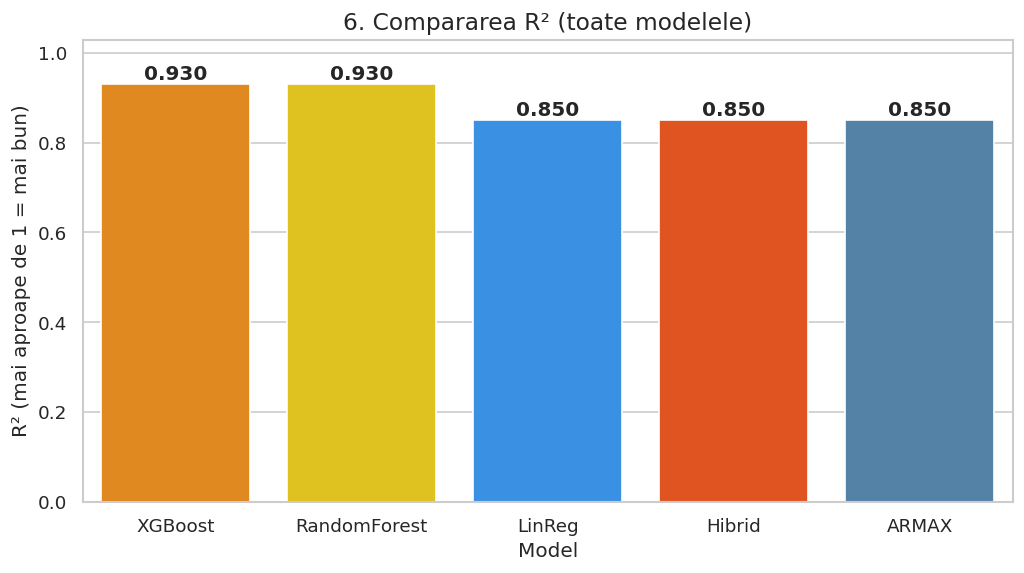

✓ Grafic 6


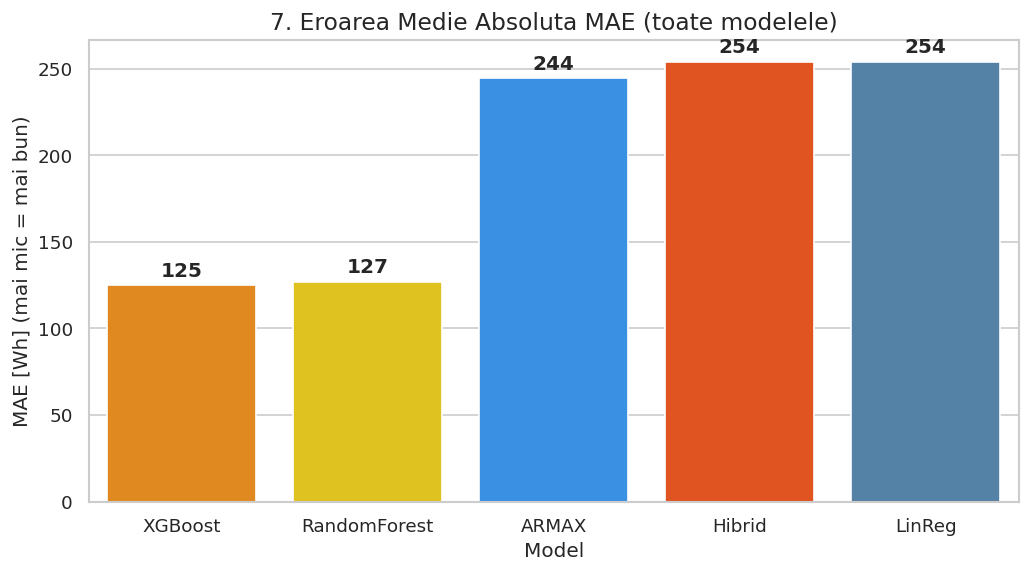

✓ Grafic 7


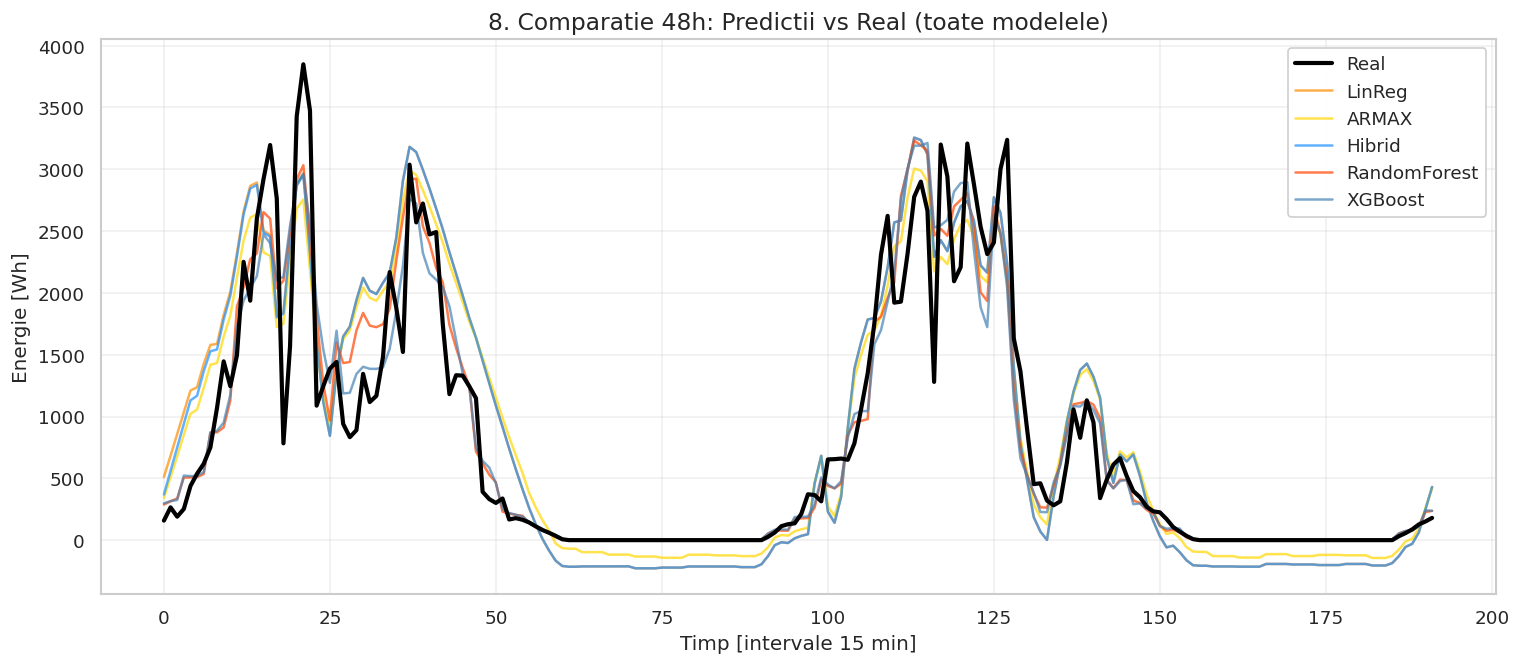

✓ Grafic 8


In [ ]:
# ============================================================================
# CELULA 13: GRAFICELE 6, 7, 8 — COMPARATIE MODELE
# ============================================================================

# Grafic 6: Bar chart R²
plt.figure(figsize=(10, 5))
sorted_r2 = metrics_df['R2'].sort_values(ascending=False)
ax = sns.barplot(x=sorted_r2.index, y=sorted_r2.values, palette=SOLAR_PALETTE)
for i, v in enumerate(sorted_r2.values):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')
plt.title('6. Compararea R² (toate modelele)', fontsize=14)
plt.ylabel('R² (mai aproape de 1 = mai bun)'); plt.xlabel('Model')
plt.ylim(0, max(1.0, sorted_r2.max() + 0.1))
plt.savefig(f'{GRAFICE_PATH}/6_barchart_r2.png'); plt.show()
print("✓ Grafic 6")

# Grafic 7: Bar chart MAE
plt.figure(figsize=(10, 5))
sorted_mae = metrics_df['MAE'].sort_values()
ax = sns.barplot(x=sorted_mae.index, y=sorted_mae.values, palette=SOLAR_PALETTE)
for i, v in enumerate(sorted_mae.values):
    ax.text(i, v + sorted_mae.max() * 0.02, f'{v:.0f}', ha='center', fontweight='bold')
plt.title('7. Eroarea Medie Absoluta MAE (toate modelele)', fontsize=14)
plt.ylabel('MAE [Wh] (mai mic = mai bun)'); plt.xlabel('Model')
plt.savefig(f'{GRAFICE_PATH}/7_barchart_mae.png'); plt.show()
print("✓ Grafic 7")

# Grafic 8: Overlay 48h
samples_48h = 4 * 24 * 2
plt.figure(figsize=(15, 6))
plt.plot(y_test.values[:samples_48h], label='Real', color='black', linewidth=2.5, zorder=10)
for idx, (name, preds) in enumerate(predictions_dict.items()):
    plt.plot(preds[:samples_48h], label=name, alpha=0.7, linewidth=1.5,
             color=SOLAR_PALETTE[idx % len(SOLAR_PALETTE)])
plt.title('8. Comparatie 48h: Predictii vs Real (toate modelele)', fontsize=14)
plt.xlabel('Timp [intervale 15 min]'); plt.ylabel('Energie [Wh]')
plt.legend(loc='upper right', framealpha=0.95); plt.grid(True, alpha=0.3)
plt.savefig(f'{GRAFICE_PATH}/8_overlay_48h.png'); plt.show()
print("✓ Grafic 8")

 TEST DIEBOLD-MARIANO (matrice p-values)
              LinReg  ARMAX  Hibrid  RandomForest  XGBoost
LinReg        1.0000    0.0  0.0015           0.0      0.0
ARMAX         0.0000    1.0  0.0000           0.0      0.0
Hibrid        0.0015    0.0  1.0000           0.0      0.0
RandomForest  0.0000    0.0  0.0000           1.0      0.0
XGBoost       0.0000    0.0  0.0000           0.0      1.0

Perechi semnificative (p<0.05): 10/10


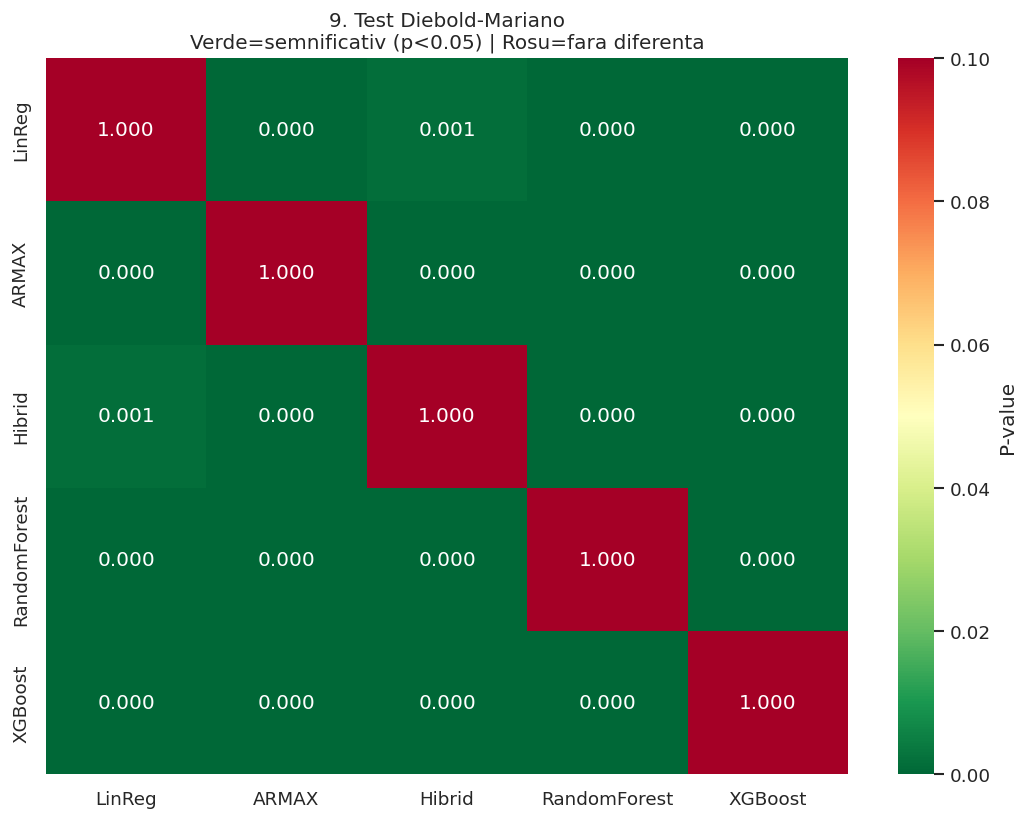

✓ Grafic 9 + CSV salvat


In [ ]:
# ============================================================================
# CELULA 14: TEST DIEBOLD-MARIANO + GRAFIC 9
# ============================================================================
print("=" * 60)
print(" TEST DIEBOLD-MARIANO (matrice p-values)")
print("=" * 60)

model_names = list(predictions_dict.keys())
n_models    = len(model_names)
dm_pvalues  = np.ones((n_models, n_models))

for i in range(n_models):
    for j in range(n_models):
        if i != j:
            _, p = diebold_mariano_test(
                y_test.values,
                predictions_dict[model_names[i]],
                predictions_dict[model_names[j]]
            )
            dm_pvalues[i, j] = p

dm_df = pd.DataFrame(dm_pvalues, index=model_names, columns=model_names)
print(dm_df.round(4).to_string())

sig_count   = (dm_pvalues < 0.05).sum() // 2
total_pairs = n_models * (n_models - 1) // 2
print(f"\nPerechi semnificative (p<0.05): {sig_count}/{total_pairs}")

# Grafic 9
plt.figure(figsize=(9, 7))
sns.heatmap(dm_df, annot=True, cmap='RdYlGn_r', vmin=0, vmax=0.1,
            fmt='.3f', cbar_kws={'label': 'P-value'})
plt.title('9. Test Diebold-Mariano\nVerde=semnificativ (p<0.05) | Rosu=fara diferenta', fontsize=12)
plt.tight_layout()
plt.savefig(f'{GRAFICE_PATH}/9_diebold_mariano.png'); plt.show()
dm_df.to_csv(f'{GRAFICE_PATH}/diebold_mariano_pvalues.csv')
print("✓ Grafic 9 + CSV salvat")

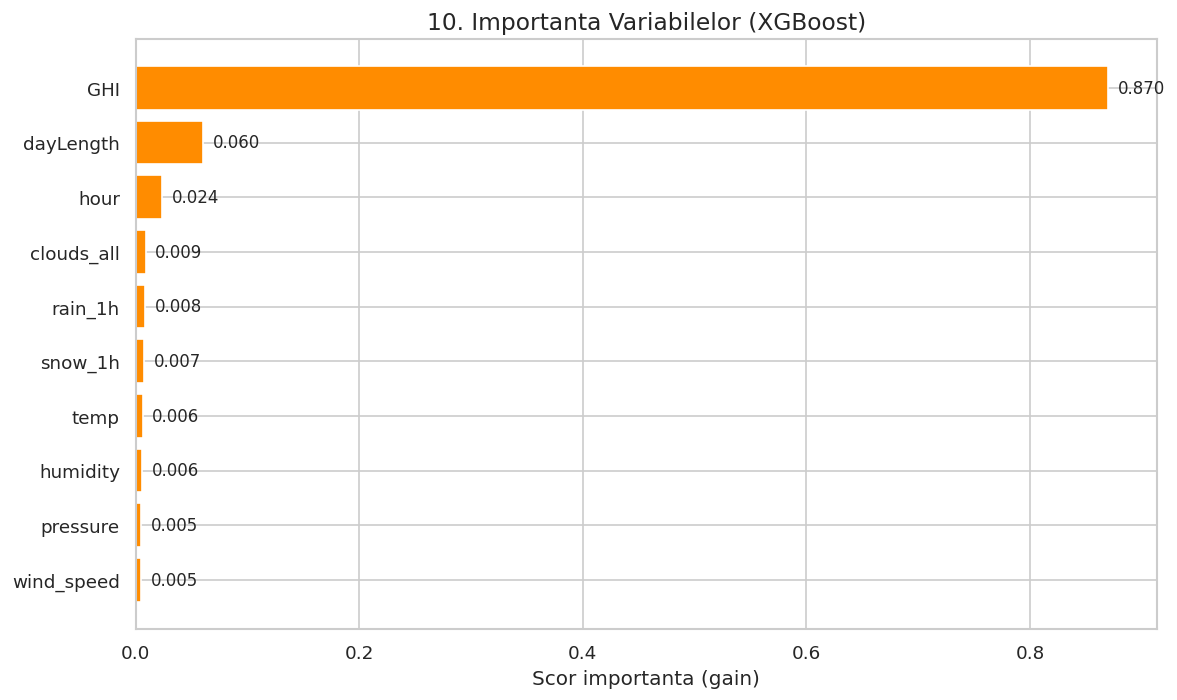

✓ Grafic 10

--- Sortat descrescator ---
   Feature  Importance
       GHI    0.870052
 dayLength    0.060361
      hour    0.023791
clouds_all    0.008779
   rain_1h    0.008142
   snow_1h    0.007363
      temp    0.006152
  humidity    0.005558
  pressure    0.004909
wind_speed    0.004893


In [ ]:
# ============================================================================
# CELULA 15: FEATURE IMPORTANCE (XGBoost) + GRAFIC 10
# ============================================================================
xgb_model   = models_dict['XGBoost']
importances = xgb_model.feature_importances_
fi_df = pd.DataFrame({'Feature': FEATURES, 'Importance': importances})
fi_df = fi_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(fi_df['Feature'], fi_df['Importance'], color=SOLAR_PALETTE[0])
for i, (_, row) in enumerate(fi_df.iterrows()):
    plt.text(row['Importance'] + fi_df['Importance'].max() * 0.01, i,
             f'{row["Importance"]:.3f}', va='center', fontsize=10)
plt.title('10. Importanta Variabilelor (XGBoost)', fontsize=14)
plt.xlabel('Scor importanta (gain)')
plt.tight_layout()
plt.savefig(f'{GRAFICE_PATH}/10_feature_importance.png'); plt.show()
print("✓ Grafic 10")
print("\n--- Sortat descrescator ---")
print(fi_df.sort_values('Importance', ascending=False).to_string(index=False))

Model WINNER: XGBoost


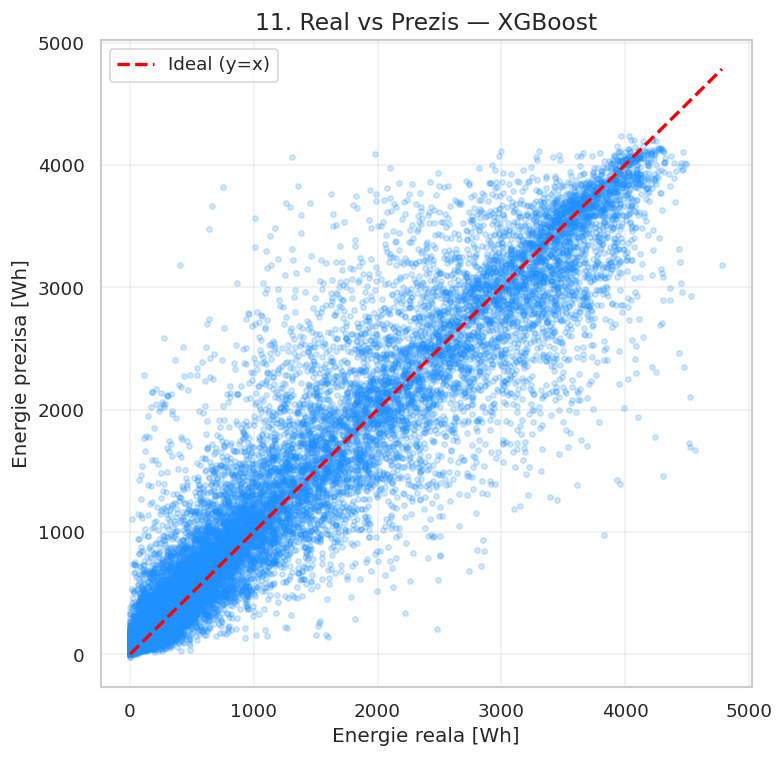

✓ Grafic 11


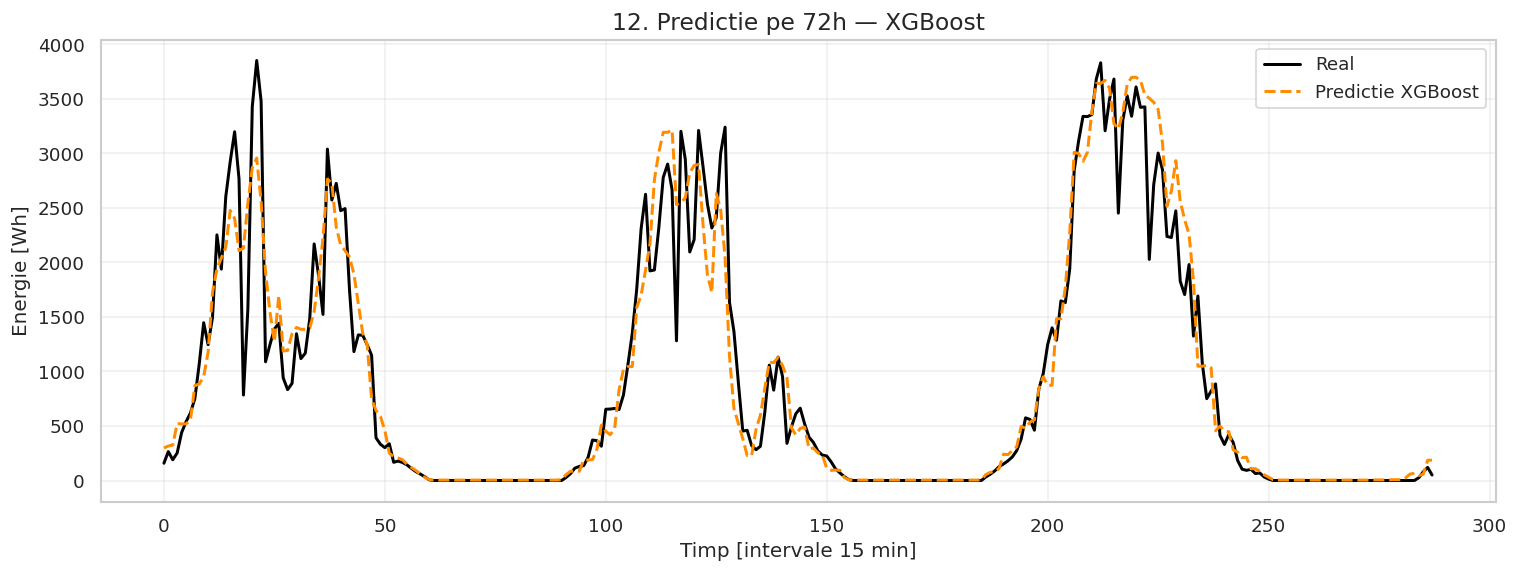

✓ Grafic 12


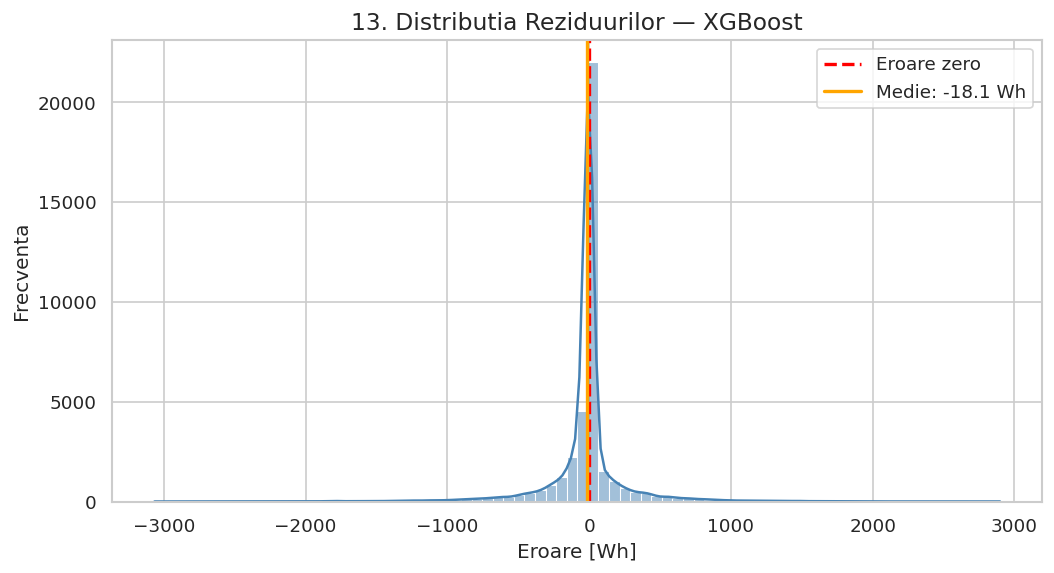

✓ Grafic 13
   Medie reziduuri: -18.13 Wh (ideal=0)
   Std reziduuri  : 282.60 Wh


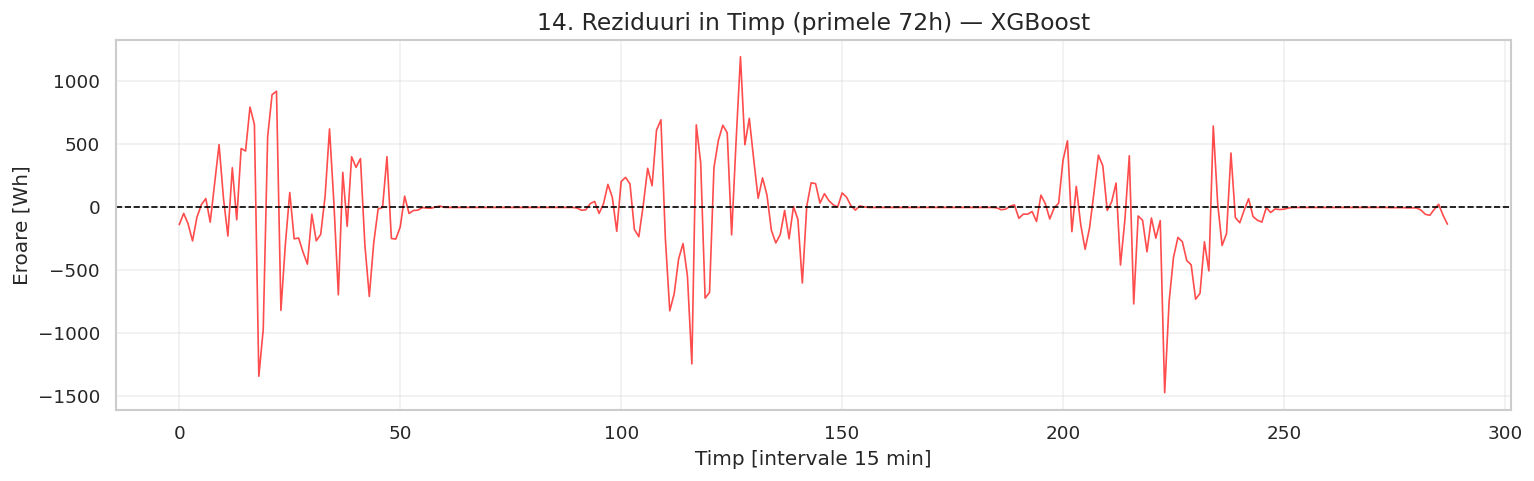

✓ Grafic 14

=== CELE 14 GRAFICE PRINCIPALE SALVATE ===


In [ ]:
# ============================================================================
# CELULA 16: ANALIZA WINNER — GRAFICELE 11, 12, 13, 14
# ============================================================================
print(f"Model WINNER: {WINNER}")
best_preds = predictions_dict[WINNER]
reziduuri  = y_test.values - best_preds
samples_72h = 4 * 24 * 3

# Grafic 11: Scatter Real vs Prezis
plt.figure(figsize=(7, 7))
plt.scatter(y_test.values, best_preds, alpha=0.2, color=SOLAR_PALETTE[2], s=10)
lim = max(y_test.max(), best_preds.max())
plt.plot([0, lim], [0, lim], 'r--', lw=2, label='Ideal (y=x)')
plt.title(f'11. Real vs Prezis — {WINNER}', fontsize=14)
plt.xlabel('Energie reala [Wh]'); plt.ylabel('Energie prezisa [Wh]')
plt.legend(); plt.grid(True, alpha=0.3)
plt.savefig(f'{GRAFICE_PATH}/11_scatter_real_vs_pred.png'); plt.show()
print("✓ Grafic 11")

# Grafic 12: Time series 72h
plt.figure(figsize=(15, 5))
plt.plot(y_test.values[:samples_72h], label='Real', color='black', linewidth=1.8)
plt.plot(best_preds[:samples_72h], label=f'Predictie {WINNER}',
         color=SOLAR_PALETTE[0], linestyle='--', linewidth=1.8)
plt.title(f'12. Predictie pe 72h — {WINNER}', fontsize=14)
plt.xlabel('Timp [intervale 15 min]'); plt.ylabel('Energie [Wh]')
plt.legend(); plt.grid(True, alpha=0.3)
plt.savefig(f'{GRAFICE_PATH}/12_timeseries_72h.png'); plt.show()
print("✓ Grafic 12")

# Grafic 13: Distributia reziduurilor
plt.figure(figsize=(10, 5))
sns.histplot(reziduuri, bins=80, color=SOLAR_PALETTE[4], kde=True)
plt.axvline(0, color='red', linestyle='--', lw=2, label='Eroare zero')
plt.axvline(np.mean(reziduuri), color='orange', lw=2,
            label=f'Medie: {np.mean(reziduuri):.1f} Wh')
plt.title(f'13. Distributia Reziduurilor — {WINNER}', fontsize=14)
plt.xlabel('Eroare [Wh]'); plt.ylabel('Frecventa'); plt.legend()
plt.savefig(f'{GRAFICE_PATH}/13_distributie_reziduuri.png'); plt.show()
print("✓ Grafic 13")
print(f"   Medie reziduuri: {np.mean(reziduuri):.2f} Wh (ideal=0)")
print(f"   Std reziduuri  : {np.std(reziduuri):.2f} Wh")

# Grafic 14: Reziduuri in timp
plt.figure(figsize=(15, 4))
plt.plot(reziduuri[:samples_72h], color='red', alpha=0.7, linewidth=1)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title(f'14. Reziduuri in Timp (primele 72h) — {WINNER}', fontsize=14)
plt.xlabel('Timp [intervale 15 min]'); plt.ylabel('Eroare [Wh]')
plt.grid(True, alpha=0.3)
plt.savefig(f'{GRAFICE_PATH}/14_reziduuri_timp.png'); plt.show()
print("✓ Grafic 14")

print("\n=== CELE 14 GRAFICE PRINCIPALE SALVATE ===")

In [ ]:
# ============================================================================
# CELULA 17: XGBOOST QUANTILE pe PR — MODELUL DE PRODUCTIE
# Separat de comparatia academica!
# Antreneaza pe ytrain_pr (PR adimensional), evalueaza pe ytest_energy_pr (Wh)
# ============================================================================
print("=" * 65)
print(" XGBOOST QUANTILE REGRESSION pe PR (model de productie)")
print("=" * 65)

start_time = time.time()

PARAMS_FINAL = {
    'max_depth':        6,
    'learning_rate':    0.05,
    'n_estimators':     600,
    'subsample':        0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 5,
    'reg_alpha':        0.1,
    'reg_lambda':       1.0,
    'gamma':            0.1,
    'random_state':     42,
    'n_jobs':           -1,
    'verbosity':        0,
}

print("1/3 P10...")
xgb_low = xgb.XGBRegressor(objective='reg:quantileerror', quantile_alpha=0.05, **PARAMS_FINAL)
xgb_low.fit(Xtrain_pr, ytrain_pr)

print("2/3 P50...")
xgb_med = xgb.XGBRegressor(objective='reg:quantileerror', quantile_alpha=0.5, **PARAMS_FINAL)
xgb_med.fit(Xtrain_pr, ytrain_pr)

print("3/3 P90...")
xgb_high = xgb.XGBRegressor(objective='reg:quantileerror', quantile_alpha=0.95, **PARAMS_FINAL)
xgb_high.fit(Xtrain_pr, ytrain_pr)

# Predictii in PR (adimensional)
pred_low_pr  = xgb_low.predict(Xtest_pr)
pred_med_pr  = xgb_med.predict(Xtest_pr)
pred_high_pr = xgb_high.predict(Xtest_pr)

# Protectie quantile crossing
pred_low_pr  = np.minimum(pred_low_pr, pred_med_pr)
pred_high_pr = np.maximum(pred_high_pr, pred_med_pr)

# Conversie PR → Wh pentru evaluare
scale_test = Xtest_pr['GHI'] * BASE_AREA * EFICIENTA_BAZA * TIMP_INTERVAL
pred_low  = pred_low_pr  * scale_test.values
pred_med  = pred_med_pr  * scale_test.values
pred_high = pred_high_pr * scale_test.values

# Metrici (fata de ytest_energy_pr, nu y_test!)
ytest_q    = ytest_energy_pr.values
mae_q50    = mean_absolute_error(ytest_q, pred_med)
r2_q50     = r2_score(ytest_q, pred_med)
in_interval = (ytest_q >= pred_low) & (ytest_q <= pred_high)
hit_rate   = in_interval.mean() * 100
avg_width  = np.mean(pred_high - pred_low)
elapsed    = time.time() - start_time

print(f"\n✓ Antrenat in {elapsed/60:.1f} min")
print(f"  MAE P50  : {mae_q50:.2f} Wh")
print(f"  R² P50   : {r2_q50:.4f}")
print(f"  Hit Rate : {hit_rate:.2f}%  (tinta ~80%)")
print(f"  Latime   : {avg_width:.1f} Wh")

if 75 <= hit_rate <= 85:
    print("  Calibrare: ✓ EXCELENTA")
elif hit_rate < 75:
    print("  Calibrare: ⚠ INTERVAL PREA INGUST")
else:
    print("  Calibrare: ⚠ INTERVAL PREA LARG")

# Salvare modele de productie
joblib.dump(xgb_low,  f'{MODELE_PATH}/xgb_quantile_p10.pkl')
joblib.dump(xgb_med,  f'{MODELE_PATH}/xgb_quantile_p50.pkl')
joblib.dump(xgb_high, f'{MODELE_PATH}/xgb_quantile_p90.pkl')
print(f"\n✓ Salvat: xgb_quantile_p10/p50/p90.pkl")

 XGBOOST QUANTILE REGRESSION pe PR (model de productie)
1/3 P10...
2/3 P50...
3/3 P90...

✓ Antrenat in 0.3 min
  MAE P50  : 241.41 Wh
  R² P50   : 0.8907
  Hit Rate : 84.34%  (tinta ~80%)
  Latime   : 891.3 Wh
  Calibrare: ✓ EXCELENTA

✓ Salvat: xgb_quantile_p10/p50/p90.pkl


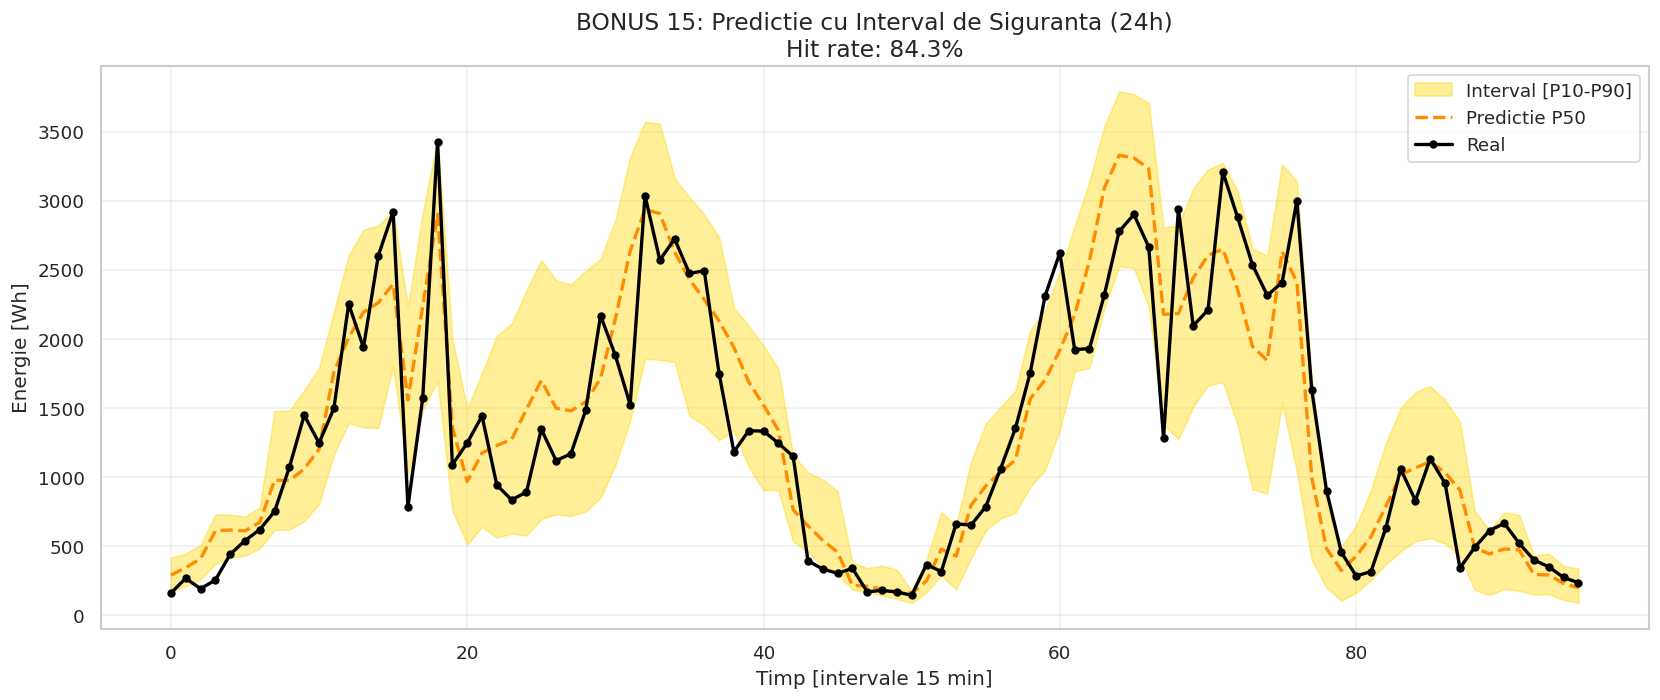

✓ Grafic 15 (24h)


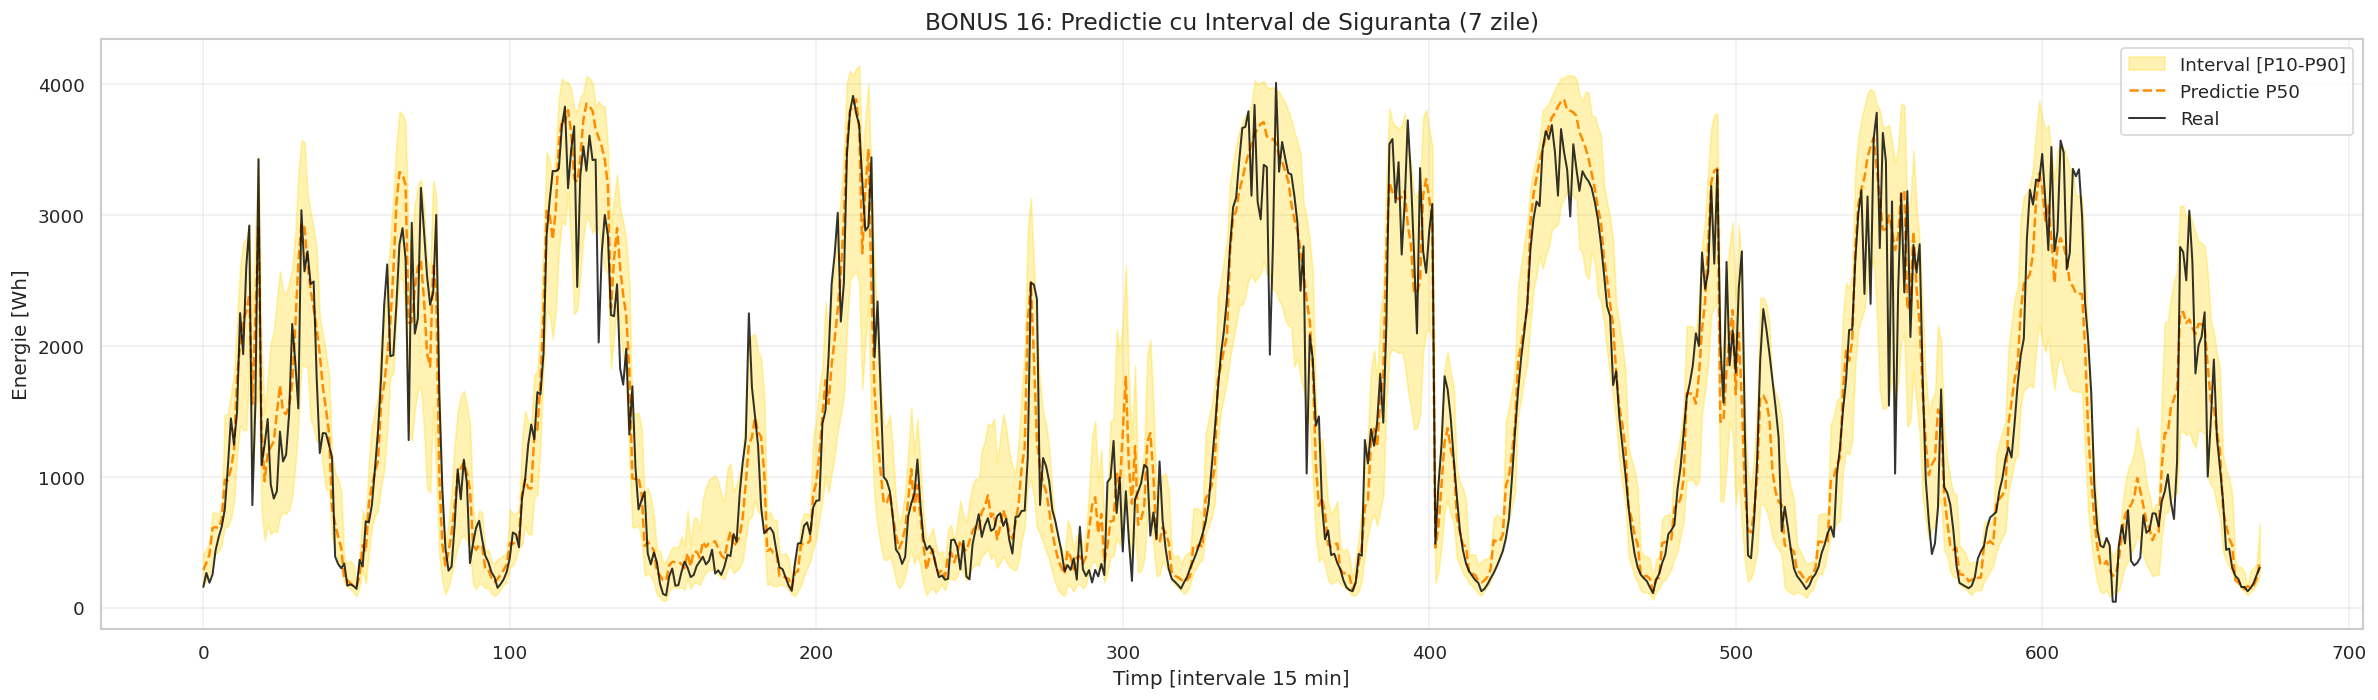

✓ Grafic 16 (7 zile)

=== TOATE 16 GRAFICE GENERATE ===


In [ ]:
# ============================================================================
# CELULA 18: GRAFICE BONUS QUANTILE — 24h si 7 zile
# ============================================================================
samples_24h = 4 * 24
samples_7d  = 4 * 24 * 7
x_24h = np.arange(samples_24h)
x_7d  = np.arange(samples_7d)

# Grafic 15: Prognoza 24h cu interval de siguranta
plt.figure(figsize=(14, 6))
plt.fill_between(x_24h, pred_low[:samples_24h], pred_high[:samples_24h],
                 color=SOLAR_PALETTE[1], alpha=0.4, label='Interval [P10-P90]')
plt.plot(x_24h, pred_med[:samples_24h],
         color=SOLAR_PALETTE[0], linestyle='--', linewidth=2, label='Predictie P50')
plt.plot(x_24h, ytest_q[:samples_24h],
         color='black', linewidth=2, marker='o', markersize=4, label='Real')
plt.title(f'BONUS 15: Predictie cu Interval de Siguranta (24h)\nHit rate: {hit_rate:.1f}%', fontsize=14)
plt.xlabel('Timp [intervale 15 min]'); plt.ylabel('Energie [Wh]')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig(f'{GRAFICE_PATH}/15_quantile_24h.png'); plt.show()
print("✓ Grafic 15 (24h)")

# Grafic 16: Prognoza 7 zile cu interval de siguranta
plt.figure(figsize=(20, 6))
plt.fill_between(x_7d, pred_low[:samples_7d], pred_high[:samples_7d],
                 color=SOLAR_PALETTE[1], alpha=0.3, label='Interval [P10-P90]')
plt.plot(x_7d, pred_med[:samples_7d],
         color=SOLAR_PALETTE[0], linestyle='--', linewidth=1.5, label='Predictie P50')
plt.plot(x_7d, ytest_q[:samples_7d],
         color='black', linewidth=1.2, alpha=0.8, label='Real')
plt.title('BONUS 16: Predictie cu Interval de Siguranta (7 zile)', fontsize=14)
plt.xlabel('Timp [intervale 15 min]'); plt.ylabel('Energie [Wh]')
plt.legend(loc='upper right'); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig(f'{GRAFICE_PATH}/16_quantile_7zile.png'); plt.show()
print("✓ Grafic 16 (7 zile)")

print("\n=== TOATE 16 GRAFICE GENERATE ===")

In [ ]:
# ============================================================================
# CELULA 19: VALIDARE INFERENTA REALA vs PVWATTS
# Simuleaza ce face Firebase la deployment
# ============================================================================
print("=" * 70)
print(" VALIDARE INFERENTA REALA — TEST CU GHI DE LA OPEN-METEO")
print("=" * 70)

AREA_USER = 25.0   # m² (sistem rezidential mic)
EFF_USER  = 0.18   # 18% eficienta
DT        = 0.25   # ore (15 min)

scenarii = [
    {"nume": "Zi senina vara, pranz",    "GHI": 850, "temp": 30, "pressure": 1013,
     "humidity": 40, "clouds_all": 5,   "rain_1h": 0, "snow_1h": 0,
     "wind_speed": 3, "dayLength": 975, "hour": 12},
    {"nume": "Zi partial noroasa vara",  "GHI": 450, "temp": 25, "pressure": 1015,
     "humidity": 55, "clouds_all": 50,  "rain_1h": 0, "snow_1h": 0,
     "wind_speed": 4, "dayLength": 975, "hour": 12},
    {"nume": "Zi noroasa vara",          "GHI": 150, "temp": 20, "pressure": 1010,
     "humidity": 75, "clouds_all": 85,  "rain_1h": 0.5, "snow_1h": 0,
     "wind_speed": 5, "dayLength": 975, "hour": 12},
    {"nume": "Zi senina vara, ora 9",    "GHI": 500, "temp": 22, "pressure": 1015,
     "humidity": 50, "clouds_all": 10,  "rain_1h": 0, "snow_1h": 0,
     "wind_speed": 2, "dayLength": 975, "hour": 9},
    {"nume": "Zi senina iarna, pranz",   "GHI": 300, "temp": 2,  "pressure": 1020,
     "humidity": 60, "clouds_all": 15,  "rain_1h": 0, "snow_1h": 0,
     "wind_speed": 4, "dayLength": 510, "hour": 12},
]

pvwatts_ref = {
    "Zi senina vara, pranz":  3800,
    "Zi partial noroasa vara": 2000,
    "Zi noroasa vara":          600,
    "Zi senina vara, ora 9":   2200,
    "Zi senina iarna, pranz":  1400,
}

print(f"Parametri utilizator: {AREA_USER} m², {EFF_USER*100:.0f}% eficienta\n")

rezultate = []
for sc in scenarii:
    # Protectie GHI<=20 (OOD, returnam 0)
    if sc['GHI'] <= 20:
        rezultate.append({"Scenariu": sc['nume'], "GHI": sc['GHI'],
                          "PR_P50": 0, "Wh/15min": 0, "Wh/ora": 0,
                          "PVWatts_ref": pvwatts_ref.get(sc['nume']), "Diff%": None})
        continue

    input_df = pd.DataFrame([[sc[f] for f in FEATURES]], columns=FEATURES)

    pr_p10 = xgb_low.predict(input_df)[0]
    pr_p50 = xgb_med.predict(input_df)[0]
    pr_p90 = xgb_high.predict(input_df)[0]
    pr_p10 = min(pr_p10, pr_p50)
    pr_p90 = max(pr_p90, pr_p50)

    # Formula de inferenta Firebase
    ghi = sc['GHI']
    e_p10_15 = pr_p10 * ghi * AREA_USER * EFF_USER * DT
    e_p50_15 = pr_p50 * ghi * AREA_USER * EFF_USER * DT
    e_p90_15 = pr_p90 * ghi * AREA_USER * EFF_USER * DT
    e_p50_h  = e_p50_15 * 4

    pvw      = pvwatts_ref.get(sc['nume'])
    diff_pct = (e_p50_h - pvw) / pvw * 100 if pvw else None
    icon     = "✓" if diff_pct and abs(diff_pct) < 25 else "⚠"

    rezultate.append({"Scenariu": sc['nume'], "GHI": ghi, "PR_P50": round(pr_p50, 3),
                      "Wh/15min": round(e_p50_15), "Wh/ora": round(e_p50_h),
                      "PVWatts_ref": pvw, "Diff%": diff_pct})

    print(f"--- {sc['nume']} ---")
    print(f"  GHI={ghi} W/m² | PR: P10={pr_p10:.3f} P50={pr_p50:.3f} P90={pr_p90:.3f}")
    print(f"  Energie: {e_p50_15:.0f} Wh/15min → {e_p50_h:.0f} Wh/h")
    print(f"  PVWatts ref: {pvw} Wh/h | Diferenta: {diff_pct:+.1f}% {icon}\n")

# Tabel rezumat
print("=" * 70)
df_rez = pd.DataFrame(rezultate)
print(df_rez.to_string(index=False, float_format="%.1f"))

diffs    = [r['Diff%'] for r in rezultate if r['Diff%'] is not None]
avg_diff = np.mean(np.abs(diffs))
max_diff = max(np.abs(diffs))
print(f"\nDiferenta medie : {avg_diff:.1f}%")
print(f"Diferenta maxima: {max_diff:.1f}%")

if avg_diff < 20:
    print(">>> ✓ EXCELENT — media sub 20%, pipeline PR functioneaza!")
elif avg_diff < 35:
    print(">>> ⚠ ACCEPTABIL — media sub 35%")
else:
    print(">>> ✗ PROBLEMATIC — verifica OOD si PR formula")
print("=" * 70)

 VALIDARE INFERENTA REALA — TEST CU GHI DE LA OPEN-METEO
Parametri utilizator: 25.0 m², 18% eficienta

--- Zi senina vara, pranz ---
  GHI=850 W/m² | PR: P10=0.824 P50=0.951 P90=1.004
  Energie: 909 Wh/15min → 3638 Wh/h
  PVWatts ref: 3800 Wh/h | Diferenta: -4.3% ✓

--- Zi partial noroasa vara ---
  GHI=450 W/m² | PR: P10=0.716 P50=0.991 P90=1.046
  Energie: 502 Wh/15min → 2007 Wh/h
  PVWatts ref: 2000 Wh/h | Diferenta: +0.4% ✓

--- Zi noroasa vara ---
  GHI=150 W/m² | PR: P10=0.452 P50=0.931 P90=1.186
  Energie: 157 Wh/15min → 628 Wh/h
  PVWatts ref: 600 Wh/h | Diferenta: +4.7% ✓

--- Zi senina vara, ora 9 ---
  GHI=500 W/m² | PR: P10=0.798 P50=1.016 P90=1.048
  Energie: 572 Wh/15min → 2287 Wh/h
  PVWatts ref: 2200 Wh/h | Diferenta: +4.0% ✓

--- Zi senina iarna, pranz ---
  GHI=300 W/m² | PR: P10=0.819 P50=1.117 P90=1.238
  Energie: 377 Wh/15min → 1507 Wh/h
  PVWatts ref: 1400 Wh/h | Diferenta: +7.7% ✓

               Scenariu  GHI  PR_P50  Wh/15min  Wh/ora  PVWatts_ref  Diff%
  Zi se

In [ ]:
# ============================================================================
# CELULA 20: EXPORT FINAL — features_list.json + system_constants.json
# ============================================================================

# features_list.json (Firebase verifica ordinea features)
features_config = {
    "features": FEATURES,
    "target": "PR (Performance Ratio, adimensional)",
    "n_features": len(FEATURES),
    "note": "Modelele quantile prezic PR. Conversia in Wh se face in backend.",
    "inference_formula": "energy_wh = PR_pred * GHI * area_user * eff_user * 0.25",
    "ghi_threshold": "GHI <= 20 W/m² → returneaza 0 Wh fara a rula modelul",
    "feature_descriptions": {
        "GHI":        "Global Horizontal Irradiance [W/m²]",
        "temp":       "Temperatura ambientala [Celsius]",
        "pressure":   "Presiune atmosferica [hPa]",
        "humidity":   "Umiditate relativa [%]",
        "clouds_all": "Acoperire nori [%]",
        "rain_1h":    "Precipitatii ultima ora [mm]",
        "snow_1h":    "Ninsori ultima ora [mm]",
        "wind_speed": "Viteza vantului [m/s]",
        "dayLength":  "Durata zilei [minute]",
        "hour":       "Ora din zi [0-23]",
    }
}
with open(f'{MODELE_PATH}/features_list.json', 'w', encoding='utf-8') as f:
    json.dump(features_config, f, indent=2, ensure_ascii=False)

# system_constants.json
system_config = {
    "base_area_m2":     BASE_AREA,
    "base_efficiency":  EFICIENTA_BAZA,
    "temp_reference_c": TEMP_REFERINTA,
    "temp_coef":        COEF_TEMP,
    "interval_hours":   TIMP_INTERVAL,
    "inference_formula": "energy_wh = PR_pred * GHI * area_user * eff_user * 0.25",
    "winning_model_comparatie": WINNER,
    "winner_metrics":   {k: float(v) for k, v in metrics_dict[WINNER].items()},
    "quantile_model":   "XGBoost Quantile Regression pe PR",
    "quantile_hit_rate_pct": float(hit_rate),
    "quantile_avg_width_wh": float(avg_width),
    "quantile_mae_p50_wh":   float(mae_q50),
    "quantile_r2_p50":       float(r2_q50),
}
with open(CONFIG_PATH, 'w', encoding='utf-8') as f:
    json.dump(system_config, f, indent=2, ensure_ascii=False)

# Sumar final
print("=" * 60)
print(" EXPORT COMPLET")
print("=" * 60)
print(f"\nFisiere in {MODELE_PATH}/:")
for fname in sorted(os.listdir(MODELE_PATH)):
    fsize = os.path.getsize(f'{MODELE_PATH}/{fname}') / 1024
    unit  = "MB" if fsize > 1024 else "KB"
    fsize = fsize / 1024 if fsize > 1024 else fsize
    print(f"  {fname:40s} {fsize:.1f} {unit}")

print(f"\nGrafice in {GRAFICE_PATH}/:")
for fname in sorted(os.listdir(GRAFICE_PATH)):
    print(f"  {fname}")

print("\n" + "=" * 60)
print(f"  WINNER comparatie : {WINNER} | MAE={metrics_dict[WINNER]['MAE']:.1f} Wh | R²={metrics_dict[WINNER]['R2']:.4f}")
print(f"  Quantile Hit Rate : {hit_rate:.1f}%")
print(f"  MAE P50 Quantile  : {mae_q50:.1f} Wh")
print(f"  Validare PVWatts  : {avg_diff:.1f}% diferenta medie")
print("=" * 60)
print("🎉 PROIECT ML COMPLET — copiaza export_modele/ in Firebase Functions")

 EXPORT COMPLET

Fisiere in /content/drive/MyDrive/ML_proiect_licenta/export_modele/:
  features_list.json                       0.9 KB
  model_armax.pkl                          63.8 MB
  model_hibrid.pkl                         275.6 MB
  model_linreg.pkl                         1.0 KB
  model_randomforest.pkl                   49.3 MB
  model_rf.pkl                             103.8 MB
  model_xgboost.pkl                        759.4 KB
  model_xgboost_comparatie.pkl             18.9 MB
  model_xgboost_pr.pkl                     14.4 MB
  rf_best_params.pkl                       0.1 KB
  xgb_best_params.pkl                      0.1 KB
  xgb_quantile_p10.pkl                     1.9 MB
  xgb_quantile_p50.pkl                     2.1 MB
  xgb_quantile_p90.pkl                     1.9 MB

Grafice in /content/drive/MyDrive/ML_proiect_licenta/grafice_export/:
  10_feature_importance.png
  11_scatter_real_vs_pred.png
  12_timeseries_72h.png
  13_distributie_reziduuri.png
  14_reziduuri_timp.